In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
import pandas as pd
import conductivity as cd

# Three-salt system

## Load the data

In [2]:
data = pd.read_csv("./Data/Three_salts_surrogate.csv")
NaCl_conc_raw = data["NaCl_conc"]
CaCl2_conc_raw = data["CaCl2_conc"]
LaCl3_conc_raw = data["LaCl3_conc"]
msa_cond_output = data["cond"]

# number of data points
ndata = len(NaCl_conc_raw)

print(data)

     NaCl_conc  CaCl2_conc  LaCl3_conc          cond
0          5.0           5           2   2413.163889
1         10.0          10           4   4554.889335
2         15.0          15           6   6562.531093
3         20.0          20           8   8478.510255
4         25.0          25          10  10325.034550
..         ...         ...         ...           ...
115        0.0           0          10   3310.476142
116        0.0           0          20   6047.697378
117        0.0           0          30   8525.828207
118        0.0           0          40  10834.575520
119        0.0           0          50  13018.812350

[120 rows x 4 columns]


## MSA Transport model constants in SI units

In [3]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diffusion_coeff = [Diff_La, Diff_Ca, Diff_Na, Diff_Cl]

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
valency = [z_La, z_Ca, z_Na, z_Cl]

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
diameter = [sigma_La, sigma_Ca, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_La_Ca_Na_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

## Develop the polynomial surrogate

### MSA model

In [4]:
# msa_cond_output = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta, epsilon, lambda_0_La_Ca_Na_Cl,
#                                    LaCl3_conc_raw, CaCl2_conc_raw, NaCl_conc_raw)

# msa_array = np.array(msa_cond_output)

# df = pd.DataFrame(msa_array, columns=["cond"])

# df.to_csv("./MSA_surrogate/cond.csv", index=False)

In [5]:
# Sample input data
df_msa = pd.DataFrame({
    'salt_1_conc': NaCl_conc_raw,
    'salt_2_conc': CaCl2_conc_raw,
    'salt_3_conc': LaCl3_conc_raw,
    "conductivity": msa_cond_output,
})

In [6]:
from idaes.core.surrogate.pysmo import polynomial_regression

# Fit a polynomial model
pr_init_msa = polynomial_regression.PolynomialRegression(regression_data_input=df_msa, original_data_input=df_msa, 
                                                         maximum_polynomial_order=2, solution_method="MLE", training_split=0.9)

features_msa = pr_init_msa.get_feature_vector()
polyfit_msa = pr_init_msa.training()



===========================Polynomial Regression===============================================


The number of cross-validation cases (3) is used.
No iterations will be run.
Parameter estimation method:  mle 

max_fraction_training_samples set at  0.5
Number of adaptive samples (no_adaptive_samples) set at  4
Maximum number of iterations (Max_iter) set at:  0

Initial surrogate model is of order 2  with a cross-val error of 3634.896161
Initial Regression Model Performance:
Order:  2  / MAE: 51.276310  / MSE: 3827.298509  / R^2: 0.999823  / Adjusted R^2: 0.999808

Polynomial regression generates a good surrogate model for the input data.

-------------------------------------------------
-------------------------------------------------
Best solution found:  
Order:  2  / MAE: 51.276310  / MSE: 3827.298509  / R_sq: 0.999823  / Adjusted R^2: 0.999808

------------------------------------------------------------
The final coefficients of the regression terms are: 

k               | 168

In [7]:
list_vars_msa = []
for i in features_msa.keys():
    list_vars_msa.append(features_msa[i])

# Pass list to generate_expression function to obtain a Pyomo expression as output
print(polyfit_msa.generate_expression(list_vars_msa))

168.01166804192587 + 108.58197313287185*IndexedParam[salt_1_conc] + 211.2420789378603*IndexedParam[salt_2_conc] + 317.7650996020812*IndexedParam[salt_3_conc] - 0.037618525899779875*IndexedParam[salt_1_conc]**2 - 0.3280058757831643*IndexedParam[salt_2_conc]**2 - 1.2452853252510536*IndexedParam[salt_3_conc]**2 - 0.2423491406977114*(IndexedParam[salt_2_conc]*IndexedParam[salt_1_conc]) - 0.5388129618200515*(IndexedParam[salt_3_conc]*IndexedParam[salt_1_conc]) - 1.30246828338107*(IndexedParam[salt_3_conc]*IndexedParam[salt_2_conc])


# Single-salt and two-salt systems prediction

In [8]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/NaCl_CaCl2_rearranged.csv")
NaCl_conc = data["NaCl conc"]
NaCl_conc12 = data["NaCl conc2"]
NaCl_conc13 = data["NaCl conc3"]
CaCl2_conc = data["CaCl2 conc"]
CaCl2_conc12 = data["CaCl2 conc2"]
CaCl2_conc13 = data["CaCl2 conc3"]
cond_exp = data["Cal bulk cond"]
cond_exp12 = data["Cal bulk cond2"]
cond_exp13 = data["Cal bulk cond3"]

# number of data points
ndata = len(cond_exp)

In [9]:
# loading CaCl2 and LaCl3 experiment data
data2 = pd.read_csv("./Data/CaCl2_LaCl3_rearranged.csv")
LaCl3_conc = data2["LaCl3 conc"]
LaCl3_conc12 = data2["LaCl3 conc2"]
LaCl3_conc13 = data2["LaCl3 conc3"]
CaCl2_conc2 = data2["CaCl2 conc"]
CaCl2_conc22 = data2["CaCl2 conc2"]
CaCl2_conc23 = data2["CaCl2 conc3"]
cond_exp2 = data2["Cal bulk cond"]
cond_exp22 = data2["Cal bulk cond2"]
cond_exp23 = data2["Cal bulk cond3"]

# number of data points
ndata2 = len(cond_exp2)

In [10]:
# loading NaCl and LaCl3 experiment data
data4 = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc2 = data4["NaCl conc"]
NaCl_conc22 = data4["NaCl conc2"]
NaCl_conc23 = data4["NaCl conc3"]
LaCl3_conc2 = data4["LaCl3 conc"]
LaCl3_conc22 = data4["LaCl3 conc2"]
LaCl3_conc23 = data4["LaCl3 conc3"]
cond_exp3 = data4["Cal bulk cond"]
cond_exp32 = data4["Cal bulk cond2"]
cond_exp33 = data4["Cal bulk cond3"]

# number of data points
ndata3 = len(cond_exp3)

## MSA Predictions

### NaCl

In [11]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
molar_conc_specific_Na = specific_data["NaCl conc"]
specific_cond_exp_Na = specific_data["NaCl cond"]
specific_cond_calibrated_Na = specific_data["NaCl cond cal"]

# number of data points
ndata4 = len(specific_cond_exp_Na)

In [12]:
# constants
T = temp
diffusion_coeff_4 = [Diff_Na, Diff_Cl] # diffusion coefficients of Na, and Cl, respectively
valency_4 = [z_Na, z_Cl] # valencies of Na, and Cl, respectively
diameter_4 = [sigma_Na, sigma_Cl] # effective ionic diameters of Na, and Cl, respectively
lambda_0_Na_Cl = [lambda_0_Na_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con4 = cd.msa_transport(valency_4, diameter_4, diffusion_coeff_4, T, eta, epsilon, lambda_0_Na_Cl, molar_conc_specific_Na)

Relaxation correction: [-0.04592817 -0.04592817]
Hydrodynamic correction: [-0.15303697 -0.09425016]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


### LaCl3

In [13]:
# loading LaCl3 specific conductivity data
specific_data = pd.read_csv("./Data/LaCl3.csv")
molar_conc_specific_La_fig = specific_data["LaCl3 conc"]
specific_cond_calibrated_La_fig = specific_data["LaCl3 cond cal"]

# number of data points
ndata_La_fig = len(specific_cond_calibrated_La_fig)

In [14]:
# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_3 = [Diff_La, Diff_Cl]
valency_3 = [z_La, z_Cl]
diameter_3 = [sigma_La, sigma_Cl]
lambda_0_La_Cl = [lambda_0_La_mol, lambda_0_Cl_mol]

# calculate the bulk conductivity using the MSA transport model
msa_cond_LaCl3 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, eta, epsilon, lambda_0_La_Cl, molar_conc_specific_La_fig)

Relaxation correction: [-0.14078865 -0.14078865]
Hydrodynamic correction: [-0.49255678 -0.13934134]
omega_bar: 236129071587.12134
Alpha: [0.0, 357917325038.36115]
Mew: [0.75 0.25]
Transport number: [0.47750064 0.52249936]
Omega: [1.50335711e+11 4.93509152e+11]
ksi: [[ 1.37883561 -0.43937499]
 [ 0.42002915  1.31812498]]


### NaCl and CaCl2

In [15]:
# constants
diffusion_coeff = [Diff_Ca, Diff_Na, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Ca, z_Na, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Ca, sigma_Na, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Ca_Na_Cl = [lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con13 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Ca_Na_Cl, CaCl2_conc13, NaCl_conc13)

Relaxation correction: [-0.10505232 -0.0376572  -0.07135476]
Hydrodynamic correction: [-0.28427357 -0.16846929 -0.10317465]
omega_bar: 339141821099.775
Alpha: [0.0, 255235452006.8003, 387504939150.9776]
Mew: [0.4 0.2 0.4]
Transport number: [0.22686909 0.19106273 0.58206818]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.61660646 -1.29858114 -0.32878394]
 [ 0.95978434  1.5459217  -1.38665899]
 [ 0.63009464  0.52562029  1.02211343]]


### NaCl and LaCl3

In [16]:
# constants
diffusion_coeff_3 = [Diff_La, Diff_Na, Diff_Cl] # diffusion coefficients of La, Na, and Cl, respectively
valency_3 = [z_La, z_Na, z_Cl] # valencies of La, Na, and Cl, respectively
diameter_3 = [sigma_La, sigma_Na, sigma_Cl] # effective ionic diameters of La, Na, and Cl, respectively
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con33 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, eta, epsilon, lambda_0_La_Na_Cl, LaCl3_conc23, NaCl_conc23)

Relaxation correction: [-0.12637798 -0.01308509 -0.11019328]
Hydrodynamic correction: [-0.36243161 -0.17069429 -0.10443014]
omega_bar: 249407449467.97238
Alpha: [0.0, 296713649948.1031, 372366303979.31903]
Mew: [0.69230769 0.03846154 0.26923077]
Transport number: [0.41730337 0.04996255 0.53273408]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.44715366 -0.45169903 -0.31313326]
 [ 0.67150534  3.76294459 -2.32471958]
 [ 0.44084061  0.62394828  1.1373026 ]]


### CaCl2 and LaCl3

In [17]:
# constants
diffusion_coeff_2 = [Diff_La, Diff_Ca, Diff_Cl] # diffusion coefficients of La, Ca, and Cl, respectively
valency_2 = [z_La, z_Ca, z_Cl] # valencies of La, Ca, and Cl, respectively
diameter_2 = [sigma_La, sigma_Ca, sigma_Cl] # effective ionic diameters of La, Ca, and Cl, respectively
lambda_0_La_Ca_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con23 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, eta, epsilon, lambda_0_La_Ca_Cl, LaCl3_conc13, CaCl2_conc23)

Relaxation correction: [-0.13488169 -0.05421643 -0.11471537]
Hydrodynamic correction: [-0.38358143 -0.30514741 -0.11020061]
omega_bar: 247450799764.53076
Alpha: [0.0, 183329743947.70795, 357686684724.24457]
Mew: [0.6        0.13333333 0.26666667]
Transport number: [0.36452267 0.10364457 0.53183276]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.4476254  -0.67880905 -0.43233384]
 [ 1.1314143   2.82094056 -0.64074538]
 [ 0.44098431  0.11685009  1.29312383]]


## Surrogate Predictions

### NaCl

In [18]:
# prediction data
CaCl2_conc_absent = [0 for _ in range(ndata4)]
LaCl3_conc_absent = [0 for _ in range(ndata4)]
input_data = np.zeros((ndata4, 3))
input_data[:, 0] = molar_conc_specific_Na
input_data[:, 1] = CaCl2_conc_absent
input_data[:, 2] = LaCl3_conc_absent
print(input_data)

# surrogate model prediction
surrogate_cond_raw = pr_init_msa.predict_output(x_data = input_data)
surrogate_cond_na = []
for i in range(len(surrogate_cond_raw)):
    surrogate_cond_na.append(surrogate_cond_raw[i, 0])

[[  1.   0.   0.]
 [  2.   0.   0.]
 [  3.   0.   0.]
 [  4.   0.   0.]
 [  5.   0.   0.]
 [ 10.   0.   0.]
 [ 20.   0.   0.]
 [ 30.   0.   0.]
 [ 40.   0.   0.]
 [ 50.   0.   0.]
 [ 60.   0.   0.]
 [ 70.   0.   0.]
 [ 80.   0.   0.]
 [ 90.   0.   0.]
 [100.   0.   0.]]


### LaCl3

In [19]:
# prediction data
CaCl2_conc_absent = [0 for _ in range(ndata_La_fig)]
NaCl_conc_absent = [0 for _ in range(ndata_La_fig)]
input_data = np.zeros((ndata_La_fig, 3))
input_data[:, 0] = NaCl_conc_absent
input_data[:, 1] = CaCl2_conc_absent
input_data[:, 2] = molar_conc_specific_La_fig
print(input_data)

# surrogate model prediction
surrogate_cond_raw = pr_init_msa.predict_output(x_data = input_data)
surrogate_cond_la = []
for i in range(len(surrogate_cond_raw)):
    surrogate_cond_la.append(surrogate_cond_raw[i, 0])

[[ 0.  0.  1.]
 [ 0.  0.  2.]
 [ 0.  0.  3.]
 [ 0.  0.  4.]
 [ 0.  0.  5.]
 [ 0.  0. 10.]
 [ 0.  0. 20.]
 [ 0.  0. 30.]
 [ 0.  0. 40.]
 [ 0.  0. 50.]]


### NaCl and LaCl3

In [20]:
# prediction data
CaCl2_conc_absent = [0 for _ in range(ndata3)]
input_data = np.zeros((ndata3, 3))
input_data[:, 0] = NaCl_conc23
input_data[:, 1] = CaCl2_conc_absent
input_data[:, 2] = LaCl3_conc23
print(input_data)

# surrogate model prediction
surrogate_cond_raw = pr_init_msa.predict_output(x_data = input_data)
surrogate_cond_na_la = []
for i in range(len(surrogate_cond_raw)):
    surrogate_cond_na_la.append(surrogate_cond_raw[i, 0])

[[ 1.  0.  2.]
 [ 2.  0.  4.]
 [ 3.  0.  6.]
 [ 4.  0.  8.]
 [ 5.  0. 10.]
 [ 6.  0. 12.]
 [ 7.  0. 14.]
 [ 8.  0. 16.]
 [ 9.  0. 18.]
 [10.  0. 20.]]


### NaCl and CaCl2

In [21]:
# prediction data
LaCl3_conc_absent = [0 for _ in range(ndata)]
input_data = np.zeros((ndata, 3))
input_data[:, 0] = NaCl_conc13
input_data[:, 1] = CaCl2_conc13
input_data[:, 2] = LaCl3_conc_absent
print(input_data)

# surrogate model prediction
surrogate_cond_raw2 = pr_init_msa.predict_output(x_data = input_data)
surrogate_cond_na_ca = []
for i in range(len(surrogate_cond_raw2)):
    surrogate_cond_na_ca.append(surrogate_cond_raw2[i, 0])

[[ 5.   2.5  0. ]
 [10.   5.   0. ]
 [15.   7.5  0. ]
 [20.  10.   0. ]
 [25.  12.5  0. ]
 [30.  15.   0. ]
 [35.  17.5  0. ]
 [40.  20.   0. ]
 [45.  22.5  0. ]
 [50.  25.   0. ]]


### CaCl2 and LaCl3

In [22]:
# prediction data
NaCl_conc_absent = [0 for _ in range(ndata2)]
input_data = np.zeros((ndata2, 3))
input_data[:, 0] = NaCl_conc_absent
input_data[:, 1] = CaCl2_conc23
input_data[:, 2] = LaCl3_conc13
print(input_data)

# surrogate model prediction
surrogate_cond_raw3 = pr_init_msa.predict_output(x_data = input_data)
surrogate_cond_ca_la = []
for i in range(len(surrogate_cond_raw3)):
    surrogate_cond_ca_la.append(surrogate_cond_raw3[i, 0])

[[ 0.  1.  2.]
 [ 0.  2.  4.]
 [ 0.  3.  6.]
 [ 0.  4.  8.]
 [ 0.  5. 10.]
 [ 0.  6. 12.]
 [ 0.  7. 14.]
 [ 0.  8. 16.]
 [ 0.  9. 18.]
 [ 0. 10. 20.]]


## Plots

### LaCl3

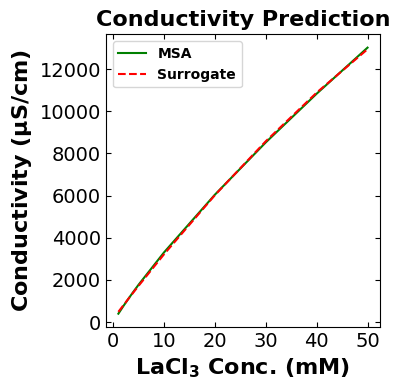

In [23]:
# making plot comparison of calculated and experimental conductivity of LaCl3
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_La_fig, msa_cond_LaCl3, color="green", label="MSA")
plt.plot(molar_conc_specific_La_fig, surrogate_cond_la, "r--", label="Surrogate")
plt.title("Conductivity Prediction", fontsize=16,fontweight='bold')
plt.xlabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_la.png")
plt.show()

### NaCl

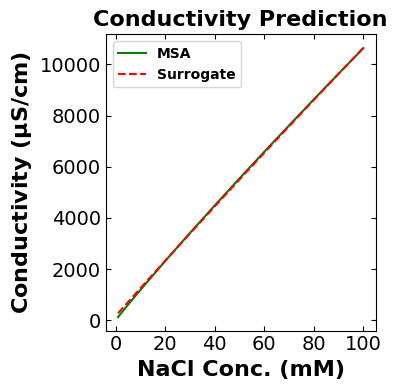

In [24]:
# making plot comparison of calculated and experimental conductivity of NaCl
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Na, all_cond_calc_con4, color="green", label="MSA")
plt.plot(molar_conc_specific_Na, surrogate_cond_na, "r--", label="Surrogate")
plt.title("Conductivity Prediction", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_na.png")
plt.show()

### NaCl and LaCl3

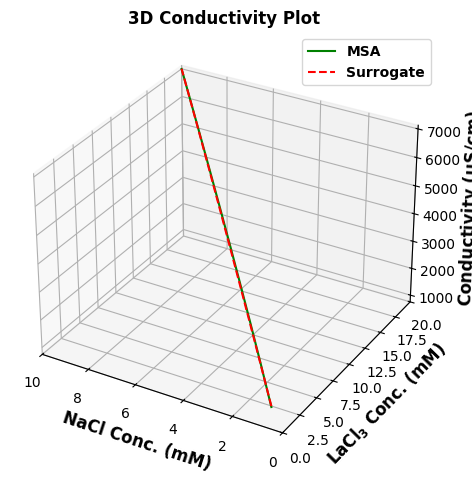

In [25]:
# making plot comparison of calculated and experimental conductivity of NaCl and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc23, LaCl3_conc23, all_cond_calc_con33, color="green", label="MSA")
ax.plot3D(NaCl_conc23, LaCl3_conc23, surrogate_cond_na_la, "r--", label="Surrogate")
ax.set_xlim(10, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_na_la.png")
plt.show()

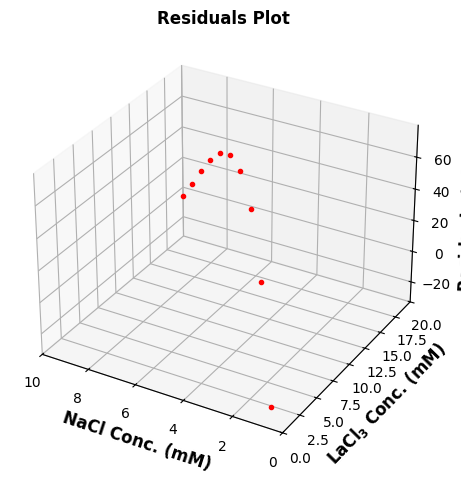

In [26]:
# residuals for NaCl and LaCl3
e33 = [all_cond_calc_con33[i] - surrogate_cond_na_la[i] for i in range(ndata3)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc23, LaCl3_conc23, e33, "r.")
ax.set_xlim(10, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_na_la_resid.png")
plt.show()

In [41]:
# residuals percent or fraction
residuals_percent33 = [100*e33[i]/all_cond_calc_con33[i] for i in range(ndata3)]

# calculate the mean absolute percent error
residuals_percent33_abs = [np.abs(residuals_percent33[i]) for i in range(ndata3)]
print(np.mean(residuals_percent33_abs))

1.612372833576115


### NaCl and CaCl2

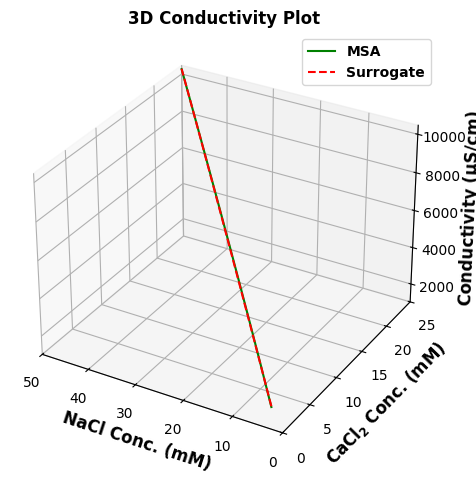

In [28]:
# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(NaCl_conc13, CaCl2_conc13, all_cond_calc_con13, color="green", label="MSA")
ax.plot3D(NaCl_conc13, CaCl2_conc13, surrogate_cond_na_ca, "r--", label="Surrogate")
ax.set_xlim(50, 0)
ax.set_ylim(0, 25)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_na_ca.png")
plt.show()

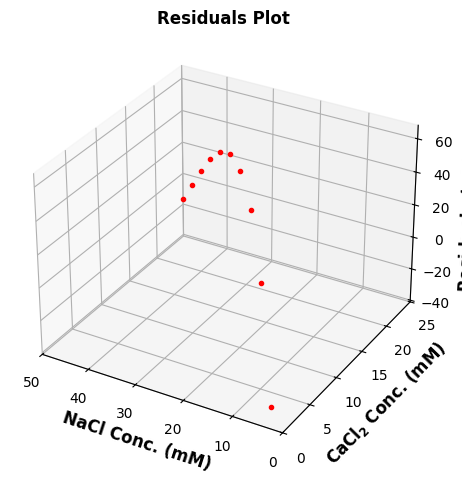

In [29]:
# residuals for NaCl and CaCl2
e13 = [all_cond_calc_con13[i] - surrogate_cond_na_ca[i] for i in range(ndata)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(NaCl_conc13, CaCl2_conc13, e13, "r.")
ax.set_xlim(50, 0)
ax.set_ylim(0, 25)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_na_ca_resid.png")
plt.show()

In [40]:
# residuals percent or fraction
residuals_percent13 = [100*e13[i]/all_cond_calc_con13[i] for i in range(ndata)]

# calculate the mean absolute percent error
residuals_percent13_abs = [np.abs(residuals_percent13[i]) for i in range(ndata)]
print(np.mean(residuals_percent13_abs))

1.0428275150295632


### CaCl2 and LaCl3

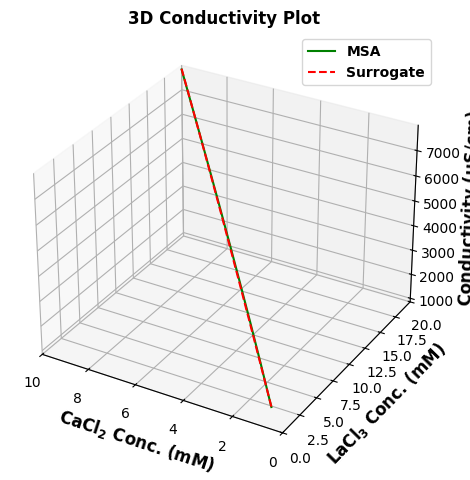

In [31]:
# making plot comparison of calculated and experimental conductivity of CaCl2 and LaCl3
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# plotting
ax.plot3D(CaCl2_conc23, LaCl3_conc13, all_cond_calc_con23, color="green", label="MSA")
ax.plot3D(CaCl2_conc23, LaCl3_conc13, surrogate_cond_ca_la, "r--", label="Surrogate")
ax.set_xlim(10, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title('3D Conductivity Plot', fontsize=12,fontweight='bold')
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_ca_la.png")
plt.show()

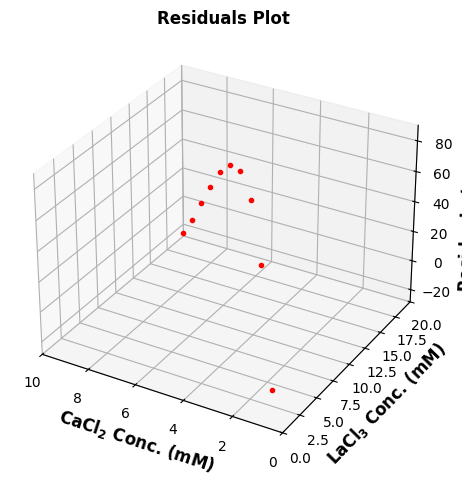

In [37]:
# residuals for CaCl2 and LaCl3
e23 = [all_cond_calc_con23[i] - surrogate_cond_ca_la[i] for i in range(ndata2)]

# making plots of residuals
fig = plt.figure()
ax = fig.add_subplot(projection ='3d')

# plotting
ax.plot3D(CaCl2_conc23, LaCl3_conc13, e23, "r.")
ax.set_xlim(10, 0)
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)
ax.set_title("Residuals Plot", fontsize=12,fontweight='bold')
ax.set_zlabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold')
ax.set_xlabel("CaCl$\mathbf{_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("LaCl$\mathbf{_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(r".\MSA_surrogate\surrogate_ca_la_resid.png")
plt.show()

In [39]:
# residuals percent or fraction
residuals_percent23 = [100*e23[i]/all_cond_calc_con23[i] for i in range(ndata2)]

# calculate the mean absolute percent error
residuals_percent23_abs = [np.abs(residuals_percent23[i]) for i in range(ndata2)]
print(np.mean(residuals_percent23_abs))

1.4320025499881814
